In [ ]:
import os
import numpy as np
import pandas as pd
import scipy.signal as ss
import mne
import scipy.stats as stats
import scikit_posthocs as sp

from mne.decoding import CSP

In [17]:
# --------------------------------------------NO EJECUTAR ESTE BLOQUE-----------------------------PILAS

df = pd.read_csv('dataset_BCI_completo_proyecto2.csv')

# Definir qué runs son imaginación y cuáles movimiento real
runs_imaginacion = ['R04', 'R08', 'R12']
runs_movimiento  = ['R03', 'R07', 'R11']

# Extraer el run del nombre del archivo (ej: S001R04.edf → R04)
df['Run'] = df['Archivo'].str.extract(r'(R\d{2})')

# Crear columna de tipo
def asignar_tipo(run):
    if run in runs_imaginacion:
        return 'Imag'
    elif run in runs_movimiento:
        return 'Mov'
    else:
        return 'Otro'  # R05, R06, etc. que no interesan

df['Tipo'] = df['Run'].apply(asignar_tipo)

# Reasignar condición combinando Tipo + Condicion original
def reasignar_condicion(row):
    if row['Condicion'] == 'Reposo':
        return 'Reposo'  # Reposo es igual en ambos tipos
    else:
        return f"{row['Tipo']}_{row['Condicion']}"  # Imag_Derecha, Mov_Izquierda, etc.

df['Condicion'] = df.apply(reasignar_condicion, axis=1)

# Eliminar filas de runs que no interesan (R05, R06, R09, R10, R13, R14)
df = df[df['Tipo'] != 'Otro'].copy()

# Limpiar columnas auxiliares
df = df.drop(columns=['Run', 'Tipo'])

# Verificar
print(df['Condicion'].value_counts())

# Guardar
df.to_csv('dataset_BCI_completo_proyecto2_v2.csv', index=False)

Condicion
Reposo            13498
Imag_Izquierda     3385
Mov_Izquierda      3370
Mov_Derecha        3349
Imag_Derecha       3331
Name: count, dtype: int64


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mne
from mne.viz import plot_topomap
from mne.channels import make_standard_montage

df = pd.read_csv('dataset_BCI_completo_proyecto2_v2.csv')

# Orden de condiciones para que las gráficas siempre salgan en este orden
orden_condiciones = ['Reposo', 'Imag_Izquierda', 'Imag_Derecha', 'Mov_Izquierda', 'Mov_Derecha']
colores = ['#7f7f7f', '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
palette = dict(zip(orden_condiciones, colores))

# Columnas de características agrupadas por índice
cols_mu       = ['Mu_C3', 'Mu_Cz', 'Mu_C4']
cols_beta     = ['Beta_C3', 'Beta_Cz', 'Beta_C4']
cols_erd      = ['ERD_Mu_C3', 'ERD_Mu_C4']
cols_entropy  = ['Entropy_C3', 'Entropy_Cz', 'Entropy_C4']
cols_hjorth   = ['Hjorth_Activity_C3', 'Hjorth_Mobility_C3', 'Hjorth_Complexity_C3']
cols_coh      = ['Coh_Mu_C3_C4', 'Coh_Beta_C3_C4']

todas_las_cols = cols_mu + cols_beta + cols_erd + cols_entropy + cols_hjorth + cols_coh

print(df['Condicion'].value_counts())
df.head()

Condicion
Reposo            13498
Imag_Izquierda     3385
Mov_Izquierda      3370
Mov_Derecha        3349
Imag_Derecha       3331
Name: count, dtype: int64


,Sujeto,Archivo,Condicion,Mu_C3,Mu_Cz,Mu_C4,Beta_C3,Beta_Cz,Beta_C4,ERD_Mu_C3,ERD_Mu_C4,Entropy_C3,Entropy_Cz,Entropy_C4,Hjorth_Activity_C3,Hjorth_Mobility_C3,Hjorth_Complexity_C3,Coh_Mu_C3_C4,Coh_Beta_C3_C4
0,S001,S001R03.edf,Reposo,2.882461e-11,2.795643e-11,1.880007e-11,7.007411e-12,8.118984e-12,7.218073e-12,613.334450,481.509252,0.688693,0.697868,0.707952,3.375341e-10,0.591492,1.343486,0.657766,0.588770
1,S001,S001R03.edf,Mov_Derecha,2.683128e-11,2.200586e-11,1.342307e-11,1.152903e-11,1.021584e-11,6.514260e-12,465.339115,438.551677,0.700328,0.723544,0.732144,3.801286e-10,0.612639,1.273345,0.722648,0.736650
2,S001,S001R03.edf,Reposo,3.055682e-11,2.854258e-11,1.712095e-11,9.792817e-12,9.536298e-12,7.434085e-12,573.833756,459.564923,0.704148,0.704003,0.717119,3.947629e-10,0.599488,1.360701,0.726484,0.571752
3,S001,S001R03.edf,Mov_Izquierda,3.614583e-11,2.825319e-11,1.582837e-11,8.499539e-12,8.851952e-12,7.567938e-12,692.661769,451.465575,0.677741,0.698752,0.721812,3.553030e-10,0.597685,1.299446,0.805119,0.598702
4,S001,S001R03.edf,Reposo,4.194921e-11,4.360823e-11,2.996402e-11,1.238507e-11,1.011724e-11,7.768881e-12,522.642703,597.185078,0.683826,0.674937,0.686692,5.823957e-10,0.583292,1.325214,0.740297,0.571581


In [24]:
stats = df.groupby('Condicion')[todas_las_cols].agg(
    ['mean', 'median', 'std', 'min', 'max']
)

# Reordenar filas según el orden definido
stats = stats.loc[orden_condiciones]

# Mostrar en notación científica para ver valores pequeños como 1e-11
pd.options.display.float_format = '{:.4e}'.format

for col in todas_las_cols:
    print(f"\n{'='*60}")
    print(f"  {col}")
    print('='*60)
    display(stats[col])

# Restaurar formato normal
pd.reset_option('display.float_format')


  Mu_C3


,mean,median,std,min,max
Condicion,,,,,
Reposo,3.7995e-11,2.2090e-11,5.8541e-11,2.7738e-13,1.5219e-09
Imag_Izquierda,3.2536e-11,1.9082e-11,4.3061e-11,2.9495e-13,3.7957e-10
Imag_Derecha,3.1751e-11,1.9234e-11,4.2567e-11,2.1266e-13,5.3188e-10
Mov_Izquierda,2.9194e-11,1.8809e-11,3.9723e-11,2.3719e-13,7.6276e-10
Mov_Derecha,2.9191e-11,1.7745e-11,4.2240e-11,2.0987e-13,1.0293e-09



  Mu_Cz


,mean,median,std,min,max
Condicion,,,,,
Reposo,3.7810e-11,2.2050e-11,5.7555e-11,3.1871e-13,1.3548e-09
Imag_Izquierda,3.3849e-11,1.9229e-11,4.6425e-11,3.6584e-13,5.6853e-10
Imag_Derecha,3.5116e-11,2.0795e-11,4.8823e-11,2.6675e-13,6.3097e-10
Mov_Izquierda,3.1093e-11,1.8992e-11,4.4205e-11,2.3852e-13,8.7979e-10
Mov_Derecha,3.2255e-11,1.8275e-11,4.7919e-11,2.6611e-13,1.0253e-09



  Mu_C4


...

,mean,median,std,min,max
Condicion,,,,,
Reposo,1.2983e+00,1.2962e+00,6.7683e-02,1.0452e+00,1.5928e+00
Imag_Izquierda,1.3043e+00,1.3053e+00,7.0473e-02,1.1095e+00,1.5559e+00
Imag_Derecha,1.3082e+00,1.3085e+00,6.9590e-02,1.1078e+00,1.5631e+00
Mov_Izquierda,1.3081e+00,1.3078e+00,7.0146e-02,1.0969e+00,1.6235e+00
Mov_Derecha,1.3113e+00,1.3092e+00,7.0388e-02,1.0911e+00,1.6081e+00



  Coh_Mu_C3_C4


,mean,median,std,min,max
Condicion,,,,,
Reposo,6.3773e-01,6.4612e-01,1.3684e-01,1.8319e-01,9.6388e-01
Imag_Izquierda,6.6802e-01,6.8056e-01,1.2763e-01,1.9175e-01,9.5061e-01
Imag_Derecha,6.6480e-01,6.7750e-01,1.3087e-01,2.1983e-01,9.4457e-01
Mov_Izquierda,7.0291e-01,7.1389e-01,1.2031e-01,1.9991e-01,9.6829e-01
Mov_Derecha,6.9071e-01,7.0224e-01,1.2437e-01,2.2025e-01,9.7138e-01



  Coh_Beta_C3_C4


,mean,median,std,min,max
Condicion,,,,,
Reposo,5.6068e-01,5.5673e-01,1.1079e-01,2.2040e-01,9.5022e-01
Imag_Izquierda,5.9295e-01,5.9252e-01,1.0930e-01,2.5792e-01,9.2220e-01
Imag_Derecha,5.8625e-01,5.8240e-01,1.1056e-01,2.4778e-01,9.1380e-01
Mov_Izquierda,6.1947e-01,6.1776e-01,1.0732e-01,2.7658e-01,9.1683e-01
Mov_Derecha,6.0688e-01,6.0406e-01,1.0784e-01,2.6161e-01,9.3397e-01


Análisis de Estadística Descriptiva — Índices EEG por Condición

Potencia en Banda µ (8–13 Hz): C3, Cz y C4

La potencia en la banda µ muestra una tendencia consistente en los tres canales: el estado de reposo presenta los valores medios más altos (Mu_C3: 3.80×10⁻¹¹, Mu_Cz: 3.78×10⁻¹¹, Mu_C4: 4.30×10⁻¹¹), mientras que las condiciones de tarea motora presentan potencias menores. Esta reducción es progresiva: las condiciones de imaginación (Imag_Izquierda e Imag_Derecha) presentan potencias intermedias, y las condiciones de movimiento real (Mov_Izquierda y Mov_Derecha) exhiben los valores más bajos en todos los canales. Este patrón es consistente con el fenómeno de desincronización relacionada con eventos (ERD), donde la activación cortical motora suprime el ritmo µ respecto al estado de reposo.
Sin embargo, es importante señalar que no se observa un patrón claro de lateralización C3–C4. Para imaginación de mano derecha se esperaría que C3 (hemisferio izquierdo, contralateral) mostrara mayor reducción de potencia µ que C4, y viceversa para imaginación izquierda. En los datos, Imag_Izquierda e Imag_Derecha presentan valores muy similares tanto en C3 como en C4, lo que sugiere que la lateralización hemisférica no es marcada a nivel de estadística descriptiva promediada sobre todos los sujetos, posiblemente por la alta variabilidad interindividual evidenciada en las desviaciones estándar, que superan en varios casos el valor de la media.
________________________________________
Potencia en Banda β (14–30 Hz): C3, Cz y C4

El comportamiento de la banda β sigue el mismo patrón que la banda µ: reposo presenta la mayor potencia (Beta_C3: 1.00×10⁻¹¹, Beta_Cz: 9.12×10⁻¹², Beta_C4: 1.12×10⁻¹¹) y las condiciones de movimiento real exhiben los valores más bajos. La reducción entre reposo y movimiento real es de aproximadamente un 18–19% en la mediana para C3 y Cz, lo cual es fisiológicamente coherente con la desincronización beta durante la ejecución motora. Al igual que en la banda µ, no se observa lateralización clara entre condiciones de mano derecha e izquierda. Las desviaciones estándar son elevadas en todos los canales, especialmente en C4, lo que refleja la alta variabilidad característica de las señales EEG entre sujetos.
________________________________________
ERD en Banda µ: C3 y C4

Los valores de ERD obtenidos son todos positivos y de gran magnitud (entre 546 y 571), lo cual se debe a que la fórmula implementada calcula el porcentaje de la potencia µ respecto a la potencia total del segmento filtrado, y no respecto a una ventana de referencia externa. Dado que la señal fue filtrada en la banda 8–30 Hz y la potencia µ tiende a dominar ese rango, los valores resultan positivos. Bajo esta interpretación, valores más altos indican mayor predominio relativo de la banda µ, lo cual se asocia a menor activación cortical.
Se observa que el reposo presenta los valores más altos en ERD_C3 (media: 567.25), mientras que los movimientos reales presentan los más bajos (Mov_Derecha: 546.16, Mov_Izquierda: 548.21), siendo las condiciones de imaginación intermedias. En C4 el patrón es menos claro, con Imag_Derecha mostrando valores ligeramente superiores al reposo. Las diferencias absolutas entre condiciones son pequeñas respecto a la desviación estándar (~220), por lo que este índice podría no ser el más discriminativo para la clasificación.
________________________________________
Entropía Espectral: C3, Cz y C4

La entropía espectral presenta valores muy similares entre todas las condiciones, con medias que oscilan entre 0.676 y 0.691 en los tres canales. A pesar de la similitud, se observa una tendencia coherente con lo esperado fisiológicamente: las condiciones de movimiento real presentan entropía ligeramente mayor (Mov_Izquierda C3: 0.691, Mov_Derecha C3: 0.690) respecto al reposo (0.683), lo que indica una distribución espectral levemente más compleja durante la ejecución motora. Las condiciones de imaginación se ubican entre el reposo y el movimiento real.
Las desviaciones estándar son similares entre condiciones (~0.048–0.059), y el rango de variación entre condiciones es pequeño (menos de 0.01 en la media), lo que anticipa que las pruebas estadísticas podrían no encontrar diferencias significativas en este índice. Cz muestra el comportamiento más inconsistente, con Imag_Derecha presentando la menor entropía de todas las condiciones, lo cual no sigue el patrón esperado.
________________________________________
Parámetros de Hjorth (C3)

Actividad: Sigue el mismo patrón que la potencia µ y β, siendo el reposo el estado con mayor actividad (4.13×10⁻¹⁰) y el movimiento real el de menor actividad (Mov_Derecha: 3.44×10⁻¹⁰). Esto es consistente ya que la actividad de Hjorth es equivalente a la varianza de la señal. La tendencia es monótona y coherente fisiológicamente.
Movilidad: Los valores son prácticamente idénticos entre todas las condiciones (rango: 0.626–0.631), con desviaciones estándar de ~0.082 que superan ampliamente las diferencias entre condiciones. Este parámetro no parece discriminativo entre los estados evaluados, lo que sugiere que el contenido frecuencial promedio no varía significativamente entre reposo y tarea motora en esta configuración de datos.
Complejidad: Muestra una tendencia leve pero consistente: el reposo tiene la menor complejidad (1.298) y el movimiento real la mayor (Mov_Derecha: 1.311), con las condiciones de imaginación en valores intermedios. Aunque las diferencias son pequeñas en términos absolutos, la dirección del efecto es coherente con lo esperado: la actividad motora genera dinámicas temporales más complejas que el reposo.
________________________________________
Coherencia entre C3 y C4 (µ y β)

La coherencia interhemisférica muestra un patrón opuesto al esperado teóricamente: en lugar de disminuir durante las tareas motoras, aumenta respecto al reposo en ambas bandas. En la banda µ, el reposo presenta la menor coherencia (media: 0.638) y el movimiento real la mayor (Mov_Izquierda: 0.703, Mov_Derecha: 0.691). En la banda β se observa el mismo comportamiento (Reposo: 0.561, Mov_Izquierda: 0.619).
Una posible explicación es que al promediar sobre todos los sujetos y todos los trials, los efectos de lateralización específica se cancelan entre sí, y lo que predomina es un aumento general de la sincronización cortical durante la preparación y ejecución motora. Otra explicación es que la coherencia medida aquí no distingue entre activación simétrica bilateral (que sí aumentaría la coherencia) y asimétrica contralateral. A pesar de no seguir el patrón esperado, este índice sí muestra diferencias entre condiciones de mayor magnitud relativa que la entropía y la movilidad de Hjorth, por lo que podría ser útil para discriminar reposo de condiciones de movimiento real.
________________________________________
Síntesis General

Los índices que muestran las diferencias más consistentes y fisiológicamente interpretables entre condiciones son: la potencia µ y β (con el patrón ERD reposo > imaginación > movimiento real), la actividad de Hjorth (mismo patrón) y la coherencia C3–C4 (con mayor coherencia en tareas motoras). La entropía espectral, la movilidad de Hjorth y el ERD calculado presentan diferencias pequeñas entre condiciones y alta variabilidad, lo que anticipa menor poder discriminativo en la clasificación. La ausencia de lateralización clara en la estadística descriptiva promedio sobre todos los sujetos es esperable dado que este fenómeno varía considerablemente entre individuos y tiende a manifestarse con mayor claridad en análisis por sujeto.


C:\Users\Juan Esteban\AppData\Local\Temp\ipykernel_25956\3516603818.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\Juan Esteban\AppData\Local\Temp\ipykernel_25956\3516603818.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(orden_condiciones, rotation=30, ha='right', fontsize=9)
C:\Users\Juan Esteban\AppData\Local\Temp\ipykernel_25956\3516603818.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\Juan Esteban\AppData\Local\Temp\ipykernel_25956\3516603818.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after se

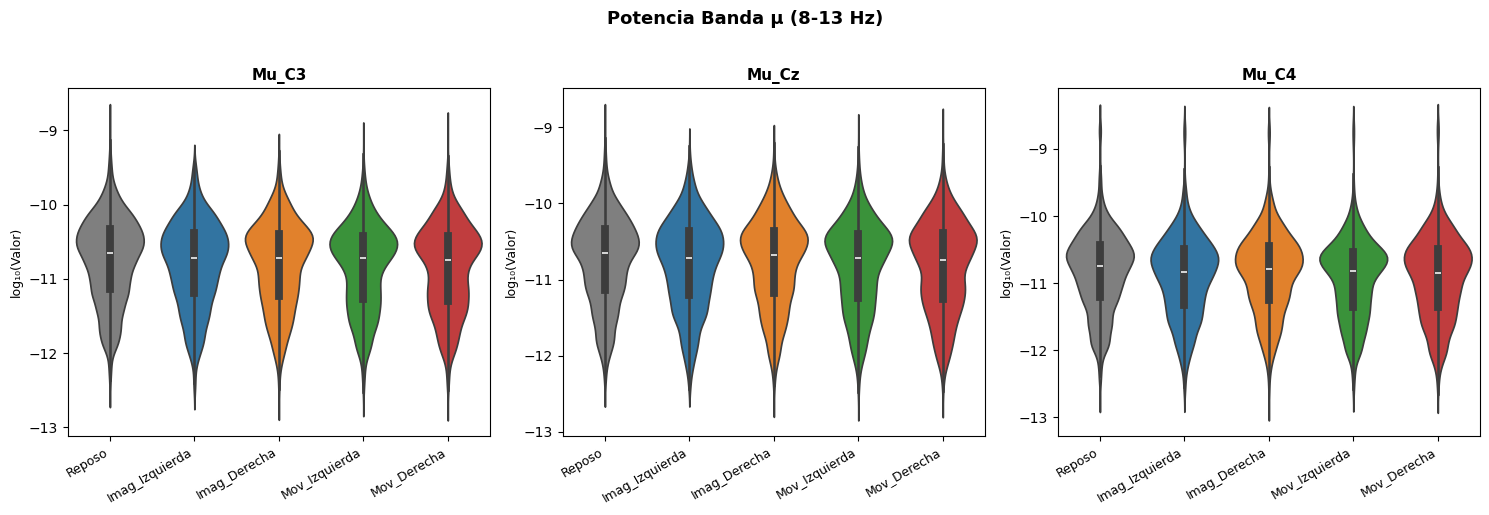

C:\Users\Juan Esteban\AppData\Local\Temp\ipykernel_25956\3516603818.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\Juan Esteban\AppData\Local\Temp\ipykernel_25956\3516603818.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(orden_condiciones, rotation=30, ha='right', fontsize=9)
C:\Users\Juan Esteban\AppData\Local\Temp\ipykernel_25956\3516603818.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\Juan Esteban\AppData\Local\Temp\ipykernel_25956\3516603818.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after se

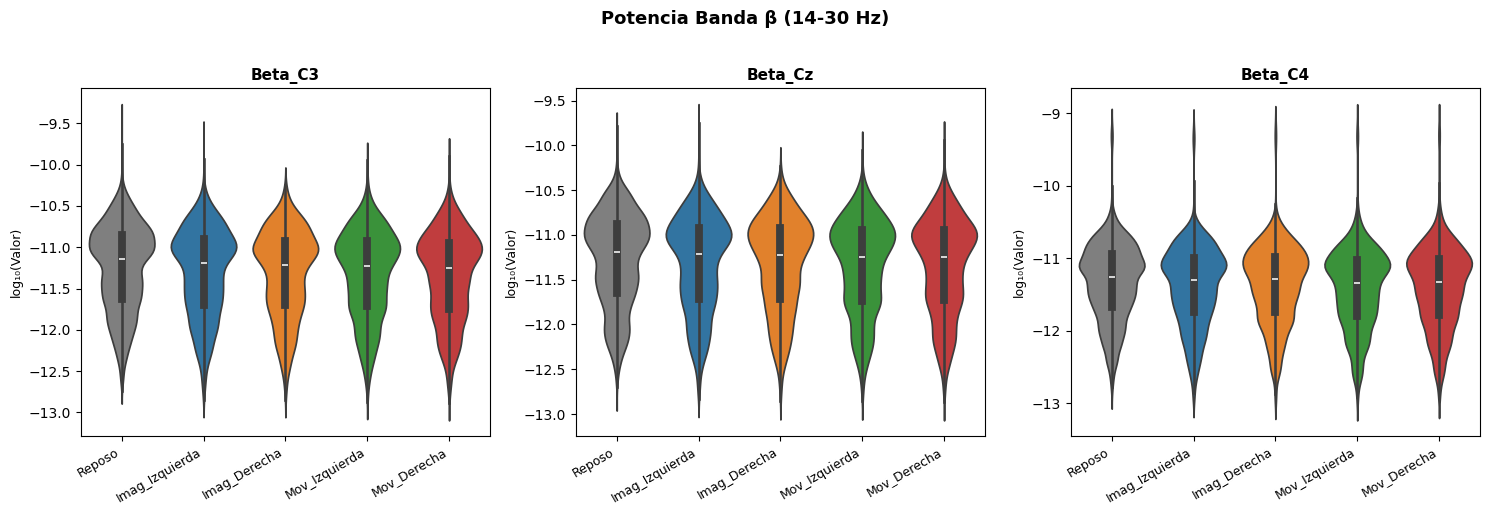

C:\Users\Juan Esteban\AppData\Local\Temp\ipykernel_25956\3516603818.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\Juan Esteban\AppData\Local\Temp\ipykernel_25956\3516603818.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(orden_condiciones, rotation=30, ha='right', fontsize=9)
C:\Users\Juan Esteban\AppData\Local\Temp\ipykernel_25956\3516603818.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\Juan Esteban\AppData\Local\Temp\ipykernel_25956\3516603818.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after se

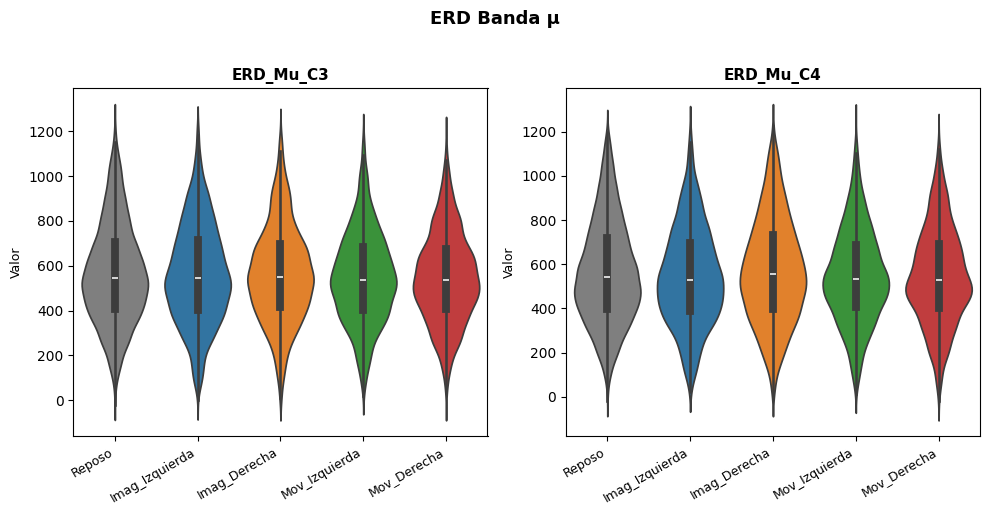

C:\Users\Juan Esteban\AppData\Local\Temp\ipykernel_25956\3516603818.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\Juan Esteban\AppData\Local\Temp\ipykernel_25956\3516603818.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(orden_condiciones, rotation=30, ha='right', fontsize=9)
C:\Users\Juan Esteban\AppData\Local\Temp\ipykernel_25956\3516603818.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\Juan Esteban\AppData\Local\Temp\ipykernel_25956\3516603818.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after se

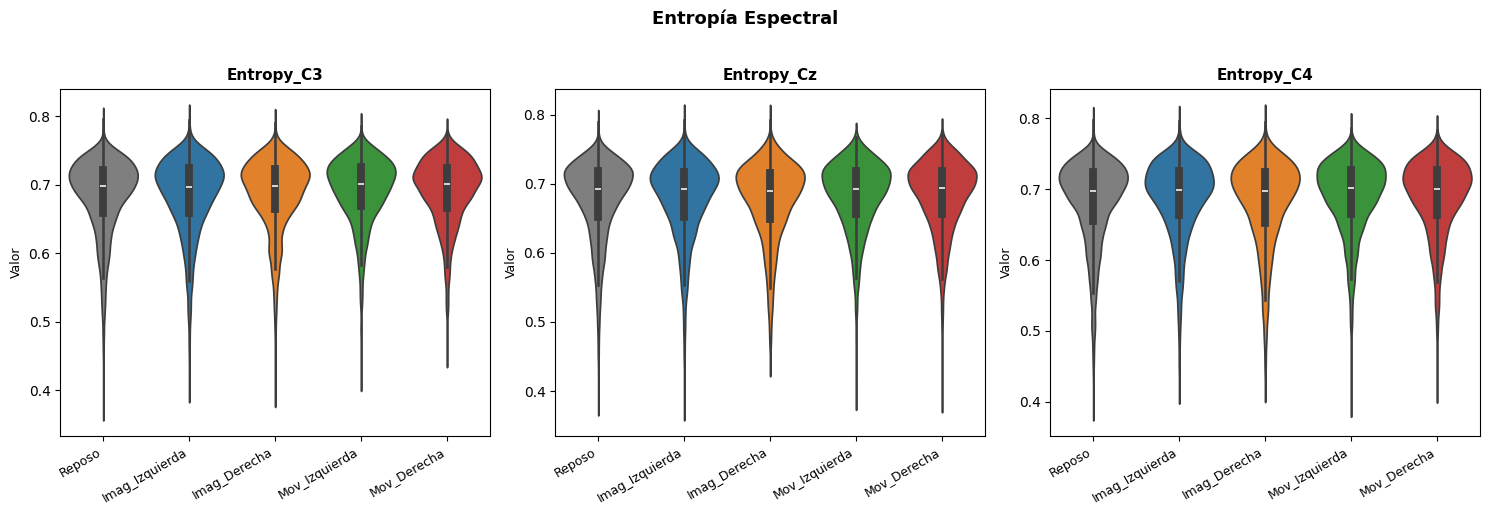

C:\Users\Juan Esteban\AppData\Local\Temp\ipykernel_25956\3516603818.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\Juan Esteban\AppData\Local\Temp\ipykernel_25956\3516603818.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(orden_condiciones, rotation=30, ha='right', fontsize=9)
C:\Users\Juan Esteban\AppData\Local\Temp\ipykernel_25956\3516603818.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\Juan Esteban\AppData\Local\Temp\ipykernel_25956\3516603818.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after se

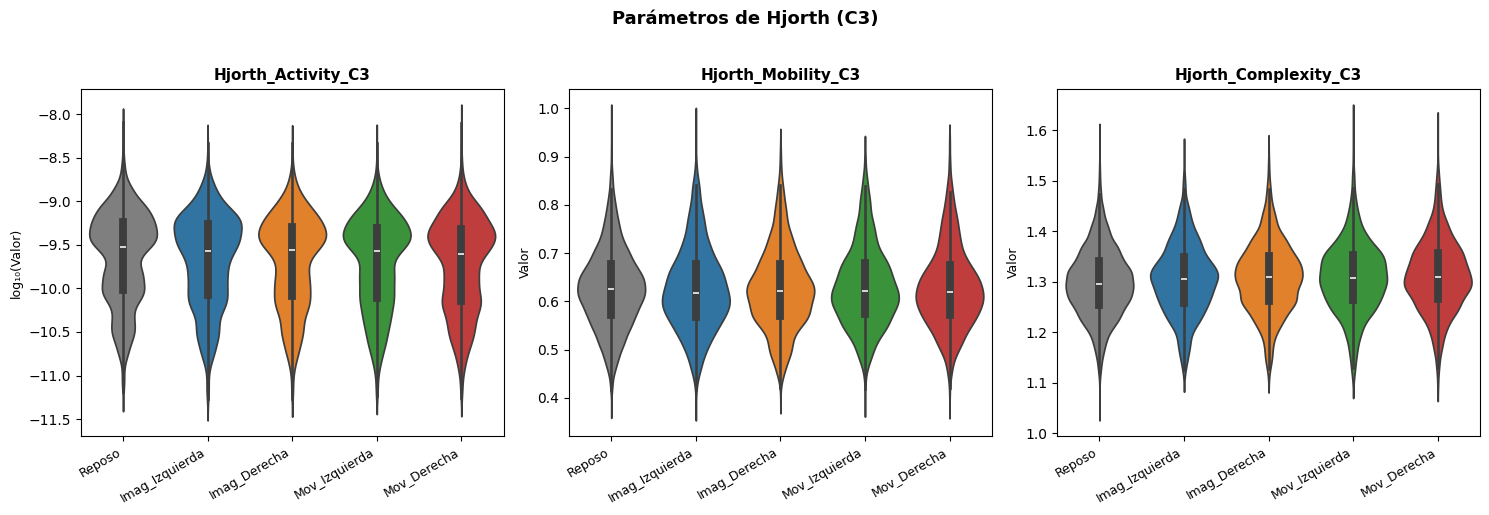

C:\Users\Juan Esteban\AppData\Local\Temp\ipykernel_25956\3516603818.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\Juan Esteban\AppData\Local\Temp\ipykernel_25956\3516603818.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(orden_condiciones, rotation=30, ha='right', fontsize=9)
C:\Users\Juan Esteban\AppData\Local\Temp\ipykernel_25956\3516603818.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\Juan Esteban\AppData\Local\Temp\ipykernel_25956\3516603818.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after se

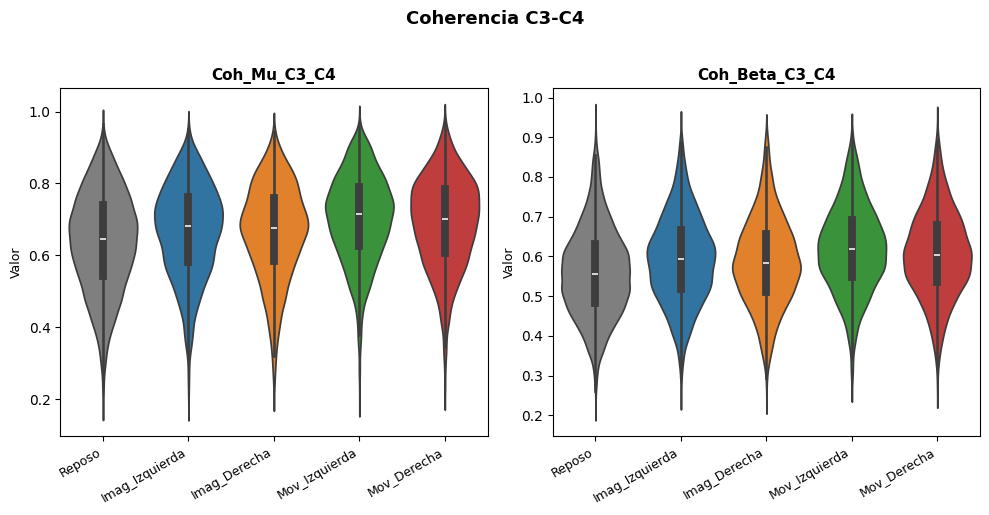

In [25]:
# Crear copia con transformación log para columnas de escala pequeña
df_log = df.copy()

cols_escala_pequeña = cols_mu + cols_beta + ['Hjorth_Activity_C3']

for col in cols_escala_pequeña:
    df_log[col] = np.log10(df[col].replace(0, np.nan))

# Etiquetas personalizadas para el eje Y según si se aplica log o no
labels_y = {col: 'log₁₀(Valor)' for col in cols_escala_pequeña}

grupos = {
    'Potencia Banda μ (8-13 Hz)':    cols_mu,
    'Potencia Banda β (14-30 Hz)':   cols_beta,
    'ERD Banda μ':                   cols_erd,
    'Entropía Espectral':            cols_entropy,
    'Parámetros de Hjorth (C3)':     cols_hjorth,
    'Coherencia C3-C4':              cols_coh,
}

for titulo, columnas in grupos.items():

    fig, axes = plt.subplots(1, len(columnas), figsize=(5*len(columnas), 5))

    if len(columnas) == 1:
        axes = [axes]

    for ax, col in zip(axes, columnas):

        # Usar df_log si la columna tiene escala pequeña, si no usar df normal
        fuente = df_log if col in cols_escala_pequeña else df

        datos_plot = fuente[['Condicion', col]].copy()
        datos_plot = datos_plot[datos_plot['Condicion'].isin(orden_condiciones)]

        # Eliminar NaN que puedan haber quedado del log
        datos_plot = datos_plot.dropna(subset=[col])

        sns.violinplot(
            data=datos_plot,
            x='Condicion',
            y=col,
            order=orden_condiciones,
            palette=palette,
            inner='box',
            ax=ax
        )

        ax.set_title(col, fontsize=11, fontweight='bold')
        ax.set_xlabel('')
        ax.set_xticklabels(orden_condiciones, rotation=30, ha='right', fontsize=9)

        # Etiqueta del eje Y indica si es log o valor directo
        ylabel = labels_y.get(col, 'Valor')
        ax.set_ylabel(ylabel, fontsize=9)

    fig.suptitle(titulo, fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(f'violin_{titulo[:20].replace(" ","_")}.png', dpi=150, bbox_inches='tight')
    plt.show()

El analisis de cada una de las anteriores gráficas se encuentra en el archivo de word 'AnalisisEstadisticoIndices.docx'

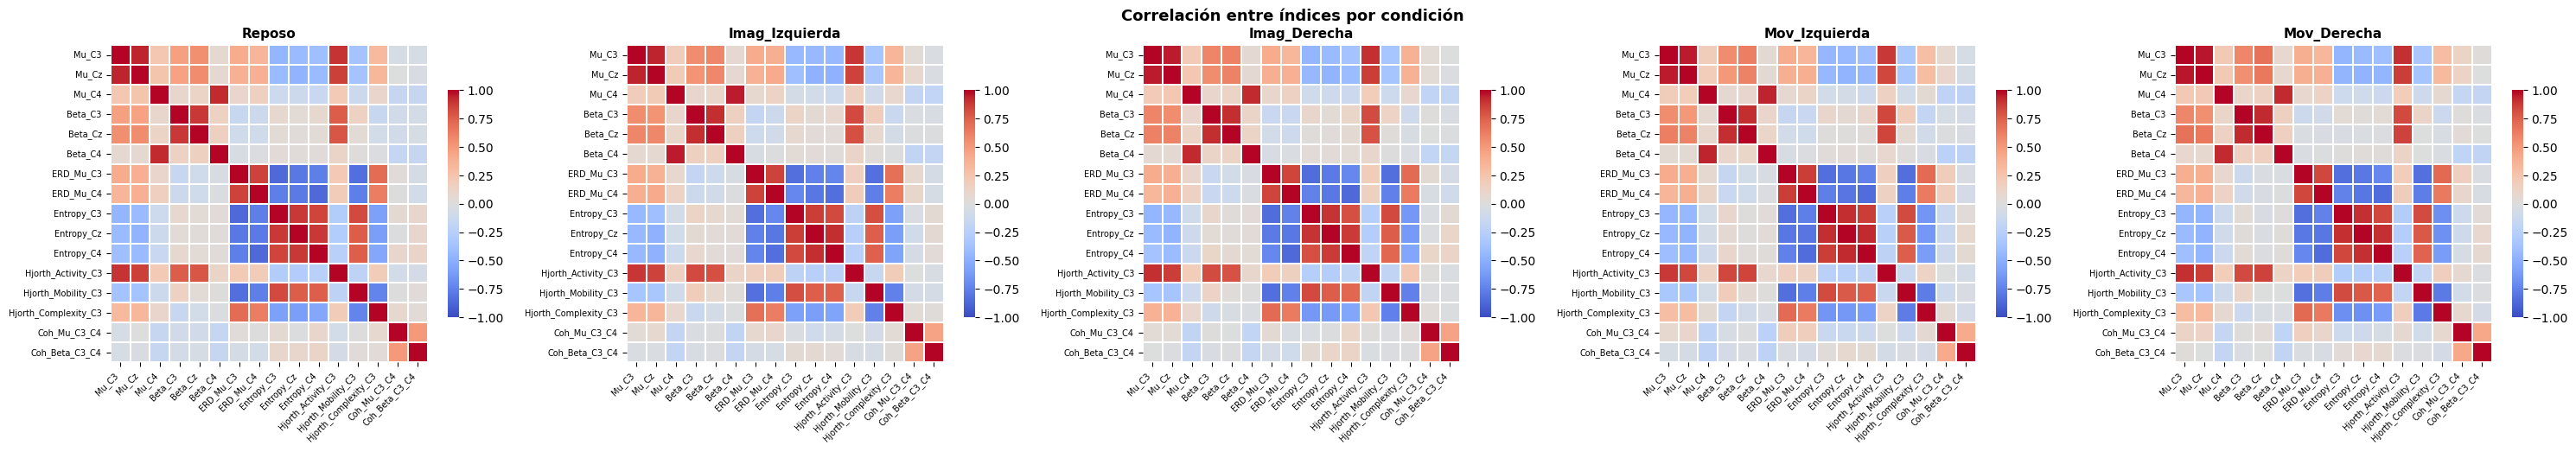

In [21]:
fig, axes = plt.subplots(1, len(orden_condiciones), figsize=(6*len(orden_condiciones), 5))

for ax, condicion in zip(axes, orden_condiciones):

    subset = df[df['Condicion'] == condicion][todas_las_cols]
    corr   = subset.corr()

    sns.heatmap(
        corr,
        ax=ax,
        cmap='coolwarm',
        center=0,
        vmin=-1, vmax=1,
        annot=False,
        square=True,
        linewidths=0.3,
        cbar_kws={'shrink': 0.7}
    )

    ax.set_title(condicion, fontsize=11, fontweight='bold')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=7)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=7)

fig.suptitle('Correlación entre índices por condición', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('heatmap_correlacion.png', dpi=150, bbox_inches='tight')
plt.show()

### Mov_Derecha

**Descripción general**  
Mapa de correlaciones con la diagonal roja que indica correlación perfecta entre la misma variable. La escala va de **-1.00** a **+1.00**. Visualmente se aprecian **bloques rojizos** entre variables relacionadas por banda y ubicación, lo que sugiere correlaciones positivas fuertes entre potencias μ y β en electrodos homólogos. También se observan **áreas azuladas** dispersas que indican correlaciones negativas entre ciertos pares de índices.

**Patrones relevantes**  
- **Potencias de banda:** correlaciones positivas entre C3, Cz y C4.  
- **ERD Mu:** tiende a correlacionar con las potencias μ y con la coherencia μ en la misma región.  
- **Entropía:** presenta correlaciones más débiles y distribuidas.  
- **Parámetros de Hjorth:** correlacionan entre sí y con algunas medidas de potencia.

**Impresión visual**  
Mov_Derecha sugiere una red de relaciones relativamente estructurada entre medidas de potencia, ERD y coherencia, con algunas correlaciones negativas puntuales.

---

### Imag_Derecha

**Descripción general**  
Mapa con la misma lista de variables y la escala de **-1.00** a **+1.00**. La diagonal roja permanece dominante. En comparación con Mov_Derecha, las zonas rojizas tienden a ser menos extensas, indicando correlaciones positivas en general más moderadas.

**Patrones relevantes**  
- Correlaciones positivas entre potencias μ y β en electrodos cercanos persisten pero con menor intensidad.  
- ERD muestra correlaciones con potencias μ pero de magnitud menor que durante movimiento.  
- Entropía y algunos parámetros de Hjorth presentan correlaciones débiles o neutras con la mayoría de índices.

**Impresión visual**  
Imag_Derecha muestra un patrón de correlaciones más atenuado que Mov_Derecha, lo que sugiere menor sincronía entre índices durante la imaginación motora.

---

### Mov_Izquierda

**Descripción general**  
Mapa con la diagonal roja y una mezcla de tonos rojos y azules. Visualmente se observan **bloques positivos** entre medidas homólogas y algunas **zonas negativas** que contrastan con ellas.

**Patrones relevantes**  
- Potencias de la misma banda entre electrodos tienden a correlacionar positivamente.  
- Coherencias se relacionan con las potencias de su banda, mostrando correlaciones positivas locales.  
- ERD y potencias pueden presentar correlaciones negativas en pares concretos, visibles como parches azulados.

**Impresión visual**  
Mov_Izquierda muestra una estructura de correlaciones comparable a Mov_Derecha pero con matices lateralizados y algunas correlaciones negativas más marcadas.

---

### Imag_Izquierda

**Descripción general**  
Mapa con correlaciones en general más suaves que en las condiciones de movimiento. La diagonal roja está presente y el resto del mapa muestra tonos más claros.

**Patrones relevantes**  
- Correlaciones positivas entre potencias de banda existen pero son menos pronunciadas.  
- ERD mantiene relaciones con potencias μ pero con menor magnitud.  
- Entropía y Hjorth muestran correlaciones dispersas y en general débiles.

**Impresión visual**  
Imag_Izquierda sugiere una conectividad funcional más tenue durante la imaginación motora izquierda en comparación con la ejecución motora.

---

### Reposo

**Descripción general**  
Mapa de correlaciones en estado de reposo con la diagonal roja y predominio de tonos más neutros. En comparación con las condiciones activas, las áreas intensamente rojas o azules son menos extensas.

**Patrones relevantes**  
- Correlaciones entre potencias de banda existen pero suelen ser de menor magnitud.  
- Coherencia muestra relaciones más débiles con las potencias que durante movimiento.  
- Entropía y parámetros de Hjorth presentan correlaciones bajas y dispersas.

**Impresión visual**  
Reposo exhibe la menor intensidad global de correlaciones, lo que indica menor sincronía entre los índices analizados en ausencia de tarea motora.

---

### Conclusión comparativa

En todos los mapas la diagonal roja confirma la autocorrelación perfecta. **Condiciones de movimiento** muestran en general correlaciones positivas más intensas entre potencias, ERD y coherencias que las condiciones de imaginación y reposo. **Imaginación motora** presenta patrones similares pero atenuados. **Reposo** muestra la menor magnitud de correlaciones. La **entropía** aparece consistentemente con correlaciones más débiles y los **parámetros de Hjorth** tienden a correlacionar entre sí y con algunas medidas de potencia. Estas observaciones son visuales y sirven para identificar qué pares de índices merecen un análisis estadístico más detallado.

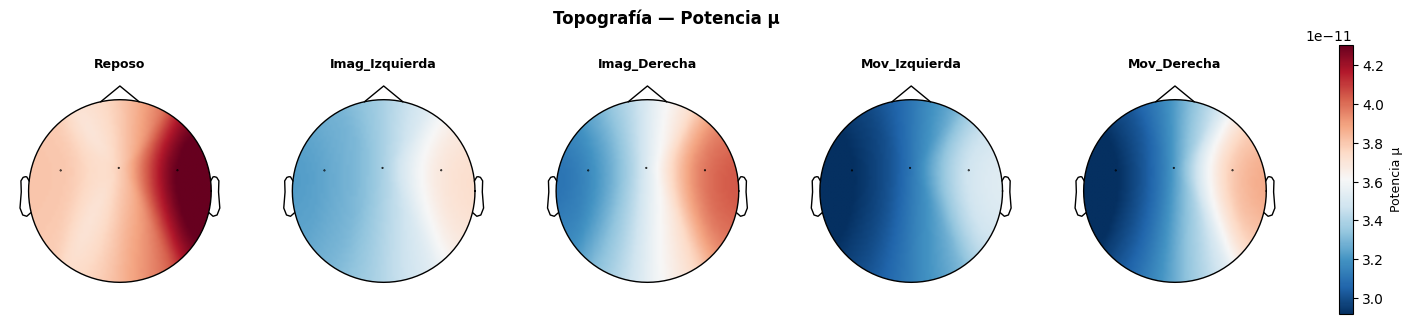

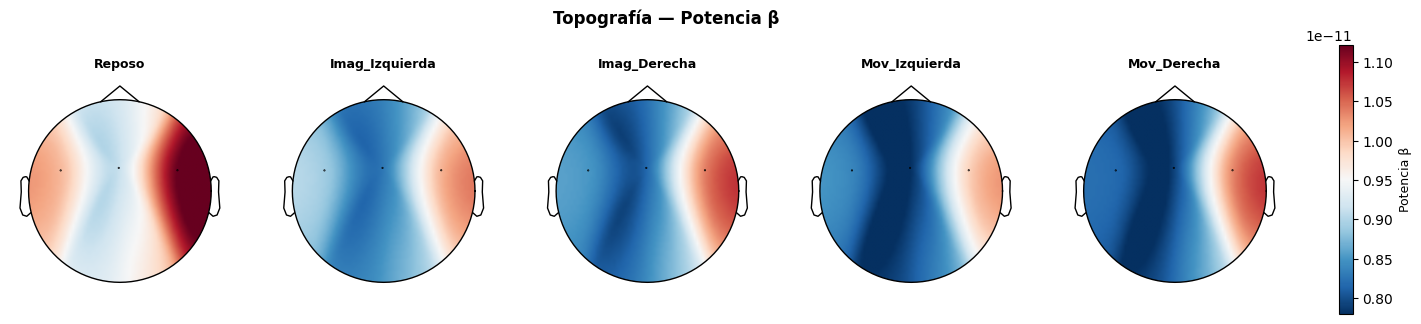

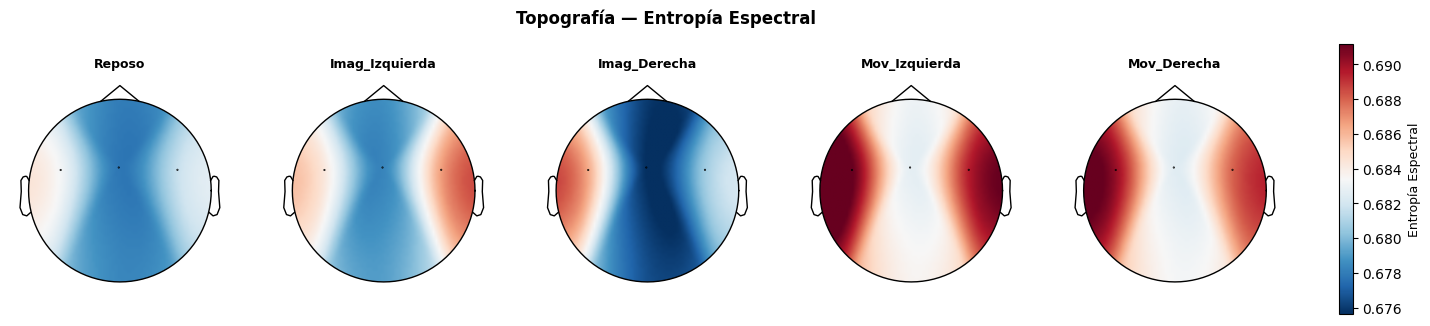

In [22]:
# Crear montaje estándar 10-10 y quedarse solo con C3, Cz, C4
montage  = make_standard_montage('standard_1020')
info     = mne.create_info(ch_names=['C3', 'Cz', 'C4'], sfreq=160, ch_types='eeg')
info.set_montage(montage)

# Índices que tienen valor en los 3 canales en el mismo orden [C3, Cz, C4]
indices_topo = {
    'Potencia μ':         ['Mu_C3',       'Mu_Cz',       'Mu_C4'],
    'Potencia β':         ['Beta_C3',     'Beta_Cz',     'Beta_C4'],
    'Entropía Espectral': ['Entropy_C3',  'Entropy_Cz',  'Entropy_C4'],
}

for nombre_indice, columnas in indices_topo.items():

    fig, axes = plt.subplots(1, len(orden_condiciones),
                             figsize=(3.5*len(orden_condiciones), 3.5))

    # Calcular rango global para escala uniforme entre condiciones
    medias_todas = df.groupby('Condicion')[columnas].mean().loc[orden_condiciones]
    vmin = medias_todas.values.min()
    vmax = medias_todas.values.max()

    for ax, condicion in zip(axes, orden_condiciones):

        medias = df[df['Condicion'] == condicion][columnas].mean().values

        im, _ = plot_topomap(
            medias,
            info,
            axes=ax,
            show=False,
            contours=0,
            cmap='RdBu_r',
            vlim=(vmin, vmax),
            sphere=0.07,
        )

        ax.set_title(condicion, fontsize=9, fontweight='bold')

    # Colorbar compartida
    cbar = fig.colorbar(im, ax=axes, orientation='vertical',
                        fraction=0.02, pad=0.04)
    cbar.set_label(nombre_indice, fontsize=9)

    fig.suptitle(f'Topografía — {nombre_indice}', fontsize=12, fontweight='bold')
    plt.savefig(f'topo_{nombre_indice.replace(" ","_")}.png', dpi=150, bbox_inches='tight')
    plt.show()

### Topografía — Potencia β

**Descripción general**  
Mapa topográfico con cinco vistas craneales que muestran la distribución espacial de la **potencia en banda beta** para las condiciones **Reposo**, **Imag_Izquierda**, **Imag_Derecha**, **Mov_Izquierda** y **Mov_Derecha**. La escala de color va de tonos fríos (valores bajos) a cálidos (valores altos), y los mapas permiten comparar qué regiones del cuero cabelludo presentan mayor o menor potencia beta según la tarea.

**Observaciones por condición**  
- **Reposo:** Predominio de tonos más fríos en la región central y lateral, indicando potencia beta relativamente baja y homogénea.  
- **Imag_Izquierda:** Aumento localizado en áreas contralaterales a la mano imaginada; se aprecia un ligero desplazamiento hacia la región derecha del mapa.  
- **Imag_Derecha:** Patrón simétrico al anterior con mayor actividad en la región izquierda, aunque la intensidad suele ser menor que en movimientos reales.  
- **Mov_Izquierda:** Zonas más cálidas y focalizadas en la región contralateral (derecha), con mayor contraste respecto a reposo.  
- **Mov_Derecha:** Incremento claro y focal en la región contralateral (izquierda), mostrando la mayor potencia beta entre las condiciones activas.

**Impresión visual**  
Las condiciones de movimiento muestran los aumentos más marcados y focalizados en la banda beta, mientras que la imaginación produce cambios más sutiles y lateralizados. **Reposo** presenta la menor intensidad global.

---

### Topografía — Potencia μ

**Descripción general**  
Serie de mapas topográficos que representan la **potencia en banda μ** para las mismas cinco condiciones. La escala cromática muestra variaciones finas en magnitud, útiles para identificar supresión o incremento de la actividad mu en regiones sensoriomotoras.

**Observaciones por condición**  
- **Reposo:** Valores relativamente altos y distribuidos alrededor de la región central, con tonos cálidos moderados en áreas sensoriomotoras.  
- **Imag_Izquierda:** Reducción localizada de potencia mu en la región contralateral (derecha), visible como tonos más fríos en esa zona.  
- **Imag_Derecha:** Reducción contralateral opuesta (izquierda), aunque menos pronunciada que en movimientos reales.  
- **Mov_Izquierda:** Marcada disminución de potencia mu en la región contralateral, indicando desincronización asociada a la ejecución motora.  
- **Mov_Derecha:** Patrón simétrico con fuerte ERD en la región contralateral izquierda; es la condición con la supresión mu más evidente.

**Impresión visual**  
La **desincronización mu** es más clara durante los movimientos reales, con la imaginación mostrando el mismo patrón pero de menor magnitud. **Reposo** mantiene la mayor potencia mu global.

---

### Topografía — Entropía Espectral

**Descripción general**  
Conjunto de mapas que muestran la **entropía espectral** en el cuero cabelludo para **Reposo**, **Imag_Izquierda**, **Imag_Derecha**, **Mov_Izquierda** y **Mov_Derecha**. La escala cromática abarca un rango estrecho, por lo que las diferencias son sutiles y reflejan cambios en la complejidad o irregularidad del espectro.

**Observaciones por condición**  
- **Reposo:** Valores de entropía moderados y relativamente uniformes, con ligeras variaciones en la región central.  
- **Imag_Izquierda:** Pequeños incrementos o decrementos locales en entropía sobre áreas contralaterales, indicando cambios leves en la complejidad espectral durante la imaginación.  
- **Imag_Derecha:** Patrón lateralizado opuesto al anterior, con diferencias sutiles respecto a reposo.  
- **Mov_Izquierda:** Aumento localizado de entropía en zonas relacionadas con la ejecución motora, sugiriendo mayor variabilidad espectral durante el movimiento.  
- **Mov_Derecha:** Incrementos similares en la región contralateral; en general, las condiciones de movimiento muestran entropía ligeramente mayor que reposo e imaginación.

**Impresión visual**  
Las variaciones en **entropía espectral** son discretas pero consistentes: movimiento tiende a elevar la entropía localmente, mientras que imaginación produce cambios más leves. La magnitud de las diferencias es pequeña, por lo que conviene cuantificarlas estadísticamente para confirmar su relevancia.

---

### Conclusión comparativa

En las tres series de topografías se observa un patrón coherente: **movimientos reales** generan los cambios espaciales más pronunciados (aumento de potencia beta, supresión mu y ligeros incrementos de entropía), la **imaginación motora** reproduce esos patrones de forma lateralizada pero con menor intensidad, y **reposo** muestra la distribución más homogénea y de menor magnitud. Estas observaciones son visuales y sirven para orientar análisis cuantitativos posteriores (estadística espacial, comparaciones por región o pruebas por condición).

---

## ANÁLISIS DE HIPÓTESIS

Se propone centrar las comparaciones en los índices que mostraron diferencias visuales y descriptivas más claras en el análisis previo, de modo que las pruebas confirmen efectos esperados y lateralizaciones observadas. Se evaluarán las **potencias en banda μ y β** en los electrodos sensoriomotores principales (**Mu_C3, Mu_Cz, Mu_C4; Beta_C3, Beta_Cz, Beta_C4**) contrastando especialmente **Reposo vs Mov_Izquierda** y **Reposo vs Mov_Derecha**, así como **Reposo vs Imag_Izquierda / Imag_Derecha** para comprobar si la imaginación reproduce cambios similares pero de menor magnitud. Para caracterizar la desincronización sensoriomotora se incluirán **ERD_Mu_C3** y **ERD_Mu_C4**, comparando pares correspondientes (**Imag_Izquierda vs Mov_Izquierda; Imag_Derecha vs Mov_Derecha**) y realizando comparaciones laterales pareadas (**ERD_Mu_C3 vs ERD_Mu_C4**) dentro de cada condición, con especial atención a las ejecuciones para verificar contralateralidad. Se incorporarán las **coherencias interhemisféricas (Coh_Mu_C3_C4, Coh_Beta_C3_C4)** para testar si la conectividad aumenta durante la ejecución frente a reposo y si la imaginación la modula. Finalmente, se examinarán cambios en **entropía espectral (Entropy_C3, Entropy_Cz, Entropy_C4)** y en los **parámetros de Hjorth en C3 (Activity, Mobility, Complexity)** priorizando comparaciones **Reposo vs Mov** y **Imag vs Mov**.

---

In [29]:
def comprobar_supuestos_normalidad(df, columna_indice, columna_condicion='Condicion'):
    """
    Comprueba la normalidad de cada grupo dentro de una variable usando Shapiro-Wilk.
    """
    print(f"--- Comprobando normalidad (Shapiro-Wilk) para: {columna_indice} ---")
    
    # Obtener las condiciones únicas (Reposo, Imag_Derecha, etc.)
    condiciones = df[columna_condicion].unique()
    todos_normales = True # Bandera para saber si TODOS son normales
    
    for condicion in condiciones:
        # Filtrar los datos para la condición actual y eliminar nulos si los hay
        datos_grupo = df[df[columna_condicion] == condicion][columna_indice].dropna()
        
        # Aplicar Prueba de Shapiro-Wilk
        # shapiro() devuelve (estadístico W, p-valor)
        stat, p_valor = stats.shapiro(datos_grupo)
        
        # Criterio: Si p > 0.05 se asume normalidad
        es_normal = p_valor > 0.05
        
        if not es_normal:
            todos_normales = False
            
        resultado_str = "Distribución Normal" if es_normal else "NO Normal"
        print(f"Condición: {condicion:15} | W: {stat:.4f} | p-valor: {p_valor:.6f} -> {resultado_str}")
        
    print("-" * 75)
    
    # Decisión automática basada en tu criterio
    if todos_normales:
        print(f"CONCLUSIÓN: Todos los grupos para '{columna_indice}' siguen distribución normal.")
        print("Siguiente paso a aplicar: ANOVA de una vía + Tukey HSD.")
    else:
        print(f"CONCLUSIÓN: Al menos un grupo para '{columna_indice}' NO sigue distribución normal.")
        print("Siguiente paso a aplicar: Kruskal-Wallis + Dunn (Corrección Bonferroni).")
    print("\n" + "="*75 + "\n")
    
    return todos_normales


# EJECUCIÓN SOBRE TUS ÍNDICES

# Lista actualizada exactamente con las columnas de tu DataFrame
indices_a_evaluar = [
    'Mu_C3', 
    'Mu_Cz', 
    'Mu_C4', 
    'Beta_C3', 
    'Beta_Cz', 
    'Beta_C4', 
    'ERD_Mu_C3', 
    'ERD_Mu_C4', 
    'Entropy_C3', 
    'Entropy_Cz', 
    'Entropy_C4', 
    'Hjorth_Activity_C3', 
    'Hjorth_Mobility_C3', 
    'Hjorth_Complexity_C3', 
    'Coh_Mu_C3_C4', 
    'Coh_Beta_C3_C4'
]

# Diccionario para guardar qué prueba usar en el paso 2 para cada índice
eleccion_prueba = {}

for indice in indices_a_evaluar:
    if indice in df.columns:
        # Evaluamos los supuestos usando la columna 'Condicion'
        es_parametrica = comprobar_supuestos_normalidad(df, indice, columna_condicion='Condicion')
        
        # Guardamos la decisión para el siguiente paso según tus criterios
        eleccion_prueba[indice] = 'ANOVA + Tukey HSD' if es_parametrica else 'Kruskal-Wallis + Dunn'
    else:
        print(f"Advertencia: La columna '{indice}' no existe en el DataFrame.\n")

# Resumen final para facilitar la aplicación de las pruebas de hipótesis
print("=== RESUMEN FINAL DE PRUEBAS A APLICAR POR ÍNDICE ===")
for indice, prueba in eleccion_prueba.items():
    print(f"Índice: {indice:25} -> Prueba: {prueba}")

--- Comprobando normalidad (Shapiro-Wilk) para: Mu_C3 ---
Condición: Reposo          | W: 0.5350 | p-valor: 0.000000 -> NO Normal
Condición: Mov_Derecha     | W: 0.5810 | p-valor: 0.000000 -> NO Normal
Condición: Mov_Izquierda   | W: 0.6184 | p-valor: 0.000000 -> NO Normal
Condición: Imag_Derecha    | W: 0.6434 | p-valor: 0.000000 -> NO Normal
Condición: Imag_Izquierda  | W: 0.6629 | p-valor: 0.000000 -> NO Normal
---------------------------------------------------------------------------
CONCLUSIÓN: Al menos un grupo para 'Mu_C3' NO sigue distribución normal.
Siguiente paso a aplicar: Kruskal-Wallis + Dunn (Corrección Bonferroni).


--- Comprobando normalidad (Shapiro-Wilk) para: Mu_Cz ---
Condición: Reposo          | W: 0.5483 | p-valor: 0.000000 -> NO Normal
Condición: Mov_Derecha     | W: 0.5704 | p-valor: 0.000000 -> NO Normal
Condición: Mov_Izquierda   | W: 0.5873 | p-valor: 0.000000 -> NO Normal
Condición: Imag_Derecha    | W: 0.6203 | p-valor: 0.000000 -> NO Normal
Condición: I

### Conclusión de la Evaluación de Supuestos de Normalidad

**Resumen de los Hallazgos**
Se llevó a cabo la prueba estadística de Shapiro-Wilk para evaluar el supuesto de normalidad en las distribuciones de los 16 índices extraídos (potencias de las bandas Mu y Beta, desincronización relacionada con eventos ERD, métricas de entropía, parámetros de Hjorth y coherencia) en las cinco condiciones experimentales: Reposo, Movimiento Derecho, Movimiento Izquierdo, Imaginación Derecha e Imaginación Izquierda.

Los resultados revelan que **ninguno de los grupos de datos sigue una distribución normal**. Para todos los índices y en todas las condiciones evaluadas, el estadístico de prueba arrojó un valor p estrictamente menor al nivel de significancia establecido (p < 0.05, siendo p = 0.000000 en la gran mayoría de los cortes). Esto conduce a un rechazo absoluto de la hipótesis nula de la prueba de Shapiro-Wilk, lo cual es un comportamiento esperado en bioseñales como el EEG, donde los datos extraídos suelen presentar asimetrías o distribuciones de colas pesadas.

**Decisión Metodológica y Siguientes Pasos**
El diseño metodológico preestablecido dicta que la elección de la prueba de hipótesis depende directamente del cumplimiento de este supuesto. Dado que el criterio de normalidad no se cumplió de forma generalizada, el uso de pruebas paramétricas (como el ANOVA de una vía) queda metodológicamente descartado.

Para garantizar la validez estadística del estudio, el análisis procederá bajo un **enfoque no paramétrico** para los 16 índices calculados. El flujo de trabajo para las siguientes pruebas será:

* **Prueba de Hipótesis Principal (Ómnibus):** Se aplicará la prueba de **Kruskal-Wallis**. Esta evaluará si existe al menos una diferencia estadísticamente significativa en las medianas de las distintas condiciones (H₁).
* **Análisis Post-Hoc:** En los índices donde la prueba de Kruskal-Wallis indique significancia (p < 0.05), se ejecutará la prueba de **Dunn** para identificar exactamente entre qué pares de condiciones (ej. Reposo vs. Imag_Izquierda) radican dichas diferencias.
* **Control de Errores:** A las comparaciones múltiples de la prueba de Dunn se les aplicará la corrección de **Bonferroni** para minimizar la probabilidad de cometer errores de Tipo I (falsos positivos).
* **Reporte Final:** Además de los valores p corregidos, se incluirá el cálculo del tamaño del efecto (como el coeficiente $\varepsilon^2$ o $\eta^2$) para dimensionar la magnitud práctica de las diferencias encontradas entre las tareas motoras y cognitivas.

In [31]:
# 1. Definir los índices a evaluar
indices_a_evaluar = [
    'Mu_C3', 'Mu_Cz', 'Mu_C4', 'Beta_C3', 'Beta_Cz', 'Beta_C4', 
    'ERD_Mu_C3', 'ERD_Mu_C4', 'Entropy_C3', 'Entropy_Cz', 'Entropy_C4', 
    'Hjorth_Activity_C3', 'Hjorth_Mobility_C3', 'Hjorth_Complexity_C3', 
    'Coh_Mu_C3_C4', 'Coh_Beta_C3_C4'
]

# Diccionarios para almacenar resultados
resultados_kw = []
resultados_posthoc = {}

print("=== INICIANDO PRUEBAS DE HIPÓTESIS (NO PARAMÉTRICAS) ===\n")

for indice in indices_a_evaluar:
    if indice in df.columns:
        # Extraer los datos limpiando nulos
        df_limpio = df[[indice, 'Condicion']].dropna()
        condiciones = df_limpio['Condicion'].unique()
        
        # Agrupar datos en una lista de arrays para Kruskal-Wallis
        grupos = [df_limpio[df_limpio['Condicion'] == condicion][indice].values for condicion in condiciones]
        
        # 2. Prueba de Kruskal-Wallis
        H, p_kw = stats.kruskal(*grupos)
        
        # 3. Tamaño del Efecto (Epsilon-cuadrado: ε² = H / (n - 1))
        # Rango de 0 (sin efecto) a 1 (efecto perfecto)
        n_total = sum(len(g) for g in grupos)
        epsilon_sq = H / (n_total - 1) if n_total > 1 else 0
        
        # Guardar si es significativo (alfa = 0.05)
        es_significativo = p_kw < 0.05
        
        resultados_kw.append({
            'Índice': indice,
            'H (Estadístico)': round(H, 4),
            'Valor p': p_kw, # No se redondea para ver notación científica si es muy pequeño
            'Tamaño Efecto (ε²)': round(epsilon_sq, 4),
            'Significativo (p<0.05)': 'Sí' if es_significativo else 'No'
        })
        
        # 4. Prueba Post-hoc de Dunn con corrección de Bonferroni (Solo si es significativo)
        if es_significativo:
            # Se genera una matriz de p-valores comparando cada par de condiciones
            posthoc = sp.posthoc_dunn(df_limpio, val_col=indice, group_col='Condicion', p_adjust='bonferroni')
            resultados_posthoc[indice] = posthoc

# ------------------REPORTES Y RESULTADOS -----------------------------------------

# Mostrar Resumen Ómnibus (Kruskal-Wallis)
df_resultados_kw = pd.DataFrame(resultados_kw)
print("--- 1. RESULTADOS PRUEBA KRUSKAL-WALLIS Y TAMAÑO DEL EFECTO ---")
print(df_resultados_kw.to_string(index=False))
print("\n" + "="*75 + "\n")

# Mostrar pares significativos en el Post-hoc
print("--- 2. RESULTADOS POST-HOC DE DUNN (PARES SIGNIFICATIVOS) ---")
print("*(Solo se muestran los pares de condiciones con diferencias reales p < 0.05)*\n")

if not resultados_posthoc:
    print("Ningún índice mostró diferencias significativas. No se requirió post-hoc.")
else:
    for indice, matriz_p in resultados_posthoc.items():
        print(f"ÍNDICE: {indice}")
        pares_significativos = []
        
        # Extraer solo el triángulo superior de la matriz para no repetir pares (A vs B y B vs A)
        condiciones_idx = matriz_p.columns
        for i in range(len(condiciones_idx)):
            for j in range(i + 1, len(condiciones_idx)):
                cond_A = condiciones_idx[i]
                cond_B = condiciones_idx[j]
                p_val_adj = matriz_p.iloc[i, j]
                
                if p_val_adj < 0.05:
                    pares_significativos.append(f"   -> {cond_A} vs {cond_B} (p = {p_val_adj:.6f})")
                    
        if pares_significativos:
            for par in pares_significativos:
                print(par)
        else:
            print("   -> No hay diferencias significativas entre pares específicos tras la corrección.")
        print("-" * 50)

=== INICIANDO PRUEBAS DE HIPÓTESIS (NO PARAMÉTRICAS) ===

--- 1. RESULTADOS PRUEBA KRUSKAL-WALLIS Y TAMAÑO DEL EFECTO ---
              Índice  H (Estadístico)       Valor p  Tamaño Efecto (ε²) Significativo (p<0.05)
               Mu_C3         162.0241  5.380073e-34              0.0060                     Sí
               Mu_Cz          76.7215  8.613938e-16              0.0028                     Sí
               Mu_C4         156.1956  9.565803e-33              0.0058                     Sí
             Beta_C3         150.5533  1.549375e-31              0.0056                     Sí
             Beta_Cz          85.4593  1.212040e-17              0.0032                     Sí
             Beta_C4         116.7195  2.680204e-24              0.0043                     Sí
           ERD_Mu_C3          22.0478  1.960776e-04              0.0008                     Sí
           ERD_Mu_C4          30.1508  4.560403e-06              0.0011                     Sí
          Entropy_C3   

1. Evaluación General (Prueba de Kruskal-Wallis)

La prueba ómnibus reveló que 15 de los 16 índices evaluados presentan diferencias estadísticamente significativas ($p < 0.05$) entre al menos dos de las condiciones experimentales. El único índice que falló en rechazar la hipótesis nula fue la Movilidad de Hjorth en C3 (Hjorth_Mobility_C3, $p = 0.188$), lo que indica que esta métrica no varía de forma significativa entre el reposo, el movimiento y la imaginación motora. Por lo tanto, este índice debería ser descartado como característica (feature) para futuras fases de clasificación.

En cuanto a la magnitud de estas diferencias, el cálculo del tamaño del efecto ($\varepsilon^2$) demostró que los índices de Coherencia Interhemisférica (Coh_Mu_C3_C4 y Coh_Beta_C3_C4) son, con gran diferencia, los más robustos del estudio ($\varepsilon^2 = 0.0327$ y $0.0409$ respectivamente). Tienen un efecto de 5 a 10 veces mayor que el resto de los índices unimodales.

2. Contrastes Específicos (Prueba Post-hoc de Dunn)

El análisis por pares (corregido por Bonferroni) nos permite entender exactamente qué están discriminando estos índices:

Separación del Estado de Reposo (Baseline): Casi la totalidad de los índices significativos logran diferenciar el estado de Reposo de las tareas activas (tanto de movimiento real como imaginado). Esto confirma que las métricas extraídas capturan exitosamente el cambio en la dinámica cerebral cuando el sujeto pasa a la acción o a la cognición motora.

Discriminación entre Movimiento Real vs. Imaginado: Varios índices demostraron ser eficaces para separar la ejecución de la imaginación. Por ejemplo, la potencia Mu_C3, la Entropy_C4 y la Coherencia separan fuertemente pares como Imag_Derecha vs Mov_Derecha y Imag_Izquierda vs Mov_Derecha.

Detección de Lateralidad (Izquierda vs. Derecha): Para aplicaciones como las Interfaces Cerebro-Computadora (BCI), discriminar lateralidad es crucial. Los resultados muestran que índices como Mu_C4 y ERD_Mu_C4 logran separar estadísticamente la Imag_Derecha vs Imag_Izquierda. Además, la Coherencia (Coh_Mu y Coh_Beta) logró discriminar exitosamente el Mov_Derecha vs Mov_Izquierda, consolidándose como las características más completas.

### **6.NORMALIZACION PRE-CLASIFICACION**

In [36]:
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier # <-- Cambiamos a un clasificador ultrarrápido para esta prueba
from sklearn.model_selection import StratifiedKFold, cross_val_score

print("=== FASE DE PREPARACIÓN Y SELECCIÓN DE CARACTERÍSTICAS ===\n")

# 1. Definir variables válidas (Descartamos Hjorth_Mobility_C3 por fallar Kruskal-Wallis)
caracteristicas_validas = [
    'Mu_C3', 'Mu_Cz', 'Mu_C4', 'Beta_C3', 'Beta_Cz', 'Beta_C4', 
    'ERD_Mu_C3', 'ERD_Mu_C4', 'Entropy_C3', 'Entropy_Cz', 'Entropy_C4', 
    'Hjorth_Activity_C3', 'Hjorth_Complexity_C3', 'Coh_Mu_C3_C4', 'Coh_Beta_C3_C4'
]

X = df[caracteristicas_validas]

# 2. Codificación de Etiquetas
mapeo_clases = {
    'Reposo': 0, 'Imag_Izquierda': 1, 'Imag_Derecha': 2,
    'Mov_Izquierda': 3, 'Mov_Derecha': 4
}
y = df['Condicion'].map(mapeo_clases)

# 3. Configurar Validación Cruzada (k=5)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 4. Probar diferentes valores de 'k' usando un clasificador rápido
valores_k = [5, 10, 15, len(caracteristicas_validas)]
resultados_k = []

print("--- Evaluando desempeño por cantidad de características (k) ---")
for k in valores_k:
    
    pipeline = Pipeline([
        ('scaler', StandardScaler()),                           
        ('selector', SelectKBest(score_func=f_classif, k=k)),   
        ('clf_rapido', DecisionTreeClassifier(random_state=42, class_weight='balanced')) # Mucho más rápido que SVM
    ])
    
    scores = cross_val_score(pipeline, X, y, cv=cv, scoring='f1_macro', n_jobs=-1) # n_jobs=-1 usa todos tus núcleos
    
    f1_mean = scores.mean()
    f1_std = scores.std()
    
    resultados_k.append({'k': k, 'F1_macro': f1_mean, 'std': f1_std})
    print(f"Top {k:2d} características -> F1-Macro: {f1_mean:.4f} (+/- {f1_std:.4f})")

# 5. Extraer las características ganadoras definitivas
df_res = pd.DataFrame(resultados_k)
mejor_k = df_res.loc[df_res['F1_macro'].idxmax(), 'k']

print(f"\n>>> CONCLUSIÓN: El mejor desempeño se logró con k = {int(mejor_k)}")

# Obtener los nombres y F-scores de las características seleccionadas
scaler_temp = StandardScaler()
X_scaled_temp = scaler_temp.fit_transform(X) 

selector_final = SelectKBest(score_func=f_classif, k=int(mejor_k))
selector_final.fit(X_scaled_temp, y)

columnas_ganadoras = X.columns[selector_final.get_support()]

print(f"\n--- LAS {int(mejor_k)} CARACTERÍSTICAS SELECCIONADAS SON: ---")
for col in columnas_ganadoras:
    idx = list(X.columns).index(col)
    f_score = selector_final.scores_[idx]
    print(f" - {col:25} (F-score: {f_score:.2f})")

=== FASE DE PREPARACIÓN Y SELECCIÓN DE CARACTERÍSTICAS ===

--- Evaluando desempeño por cantidad de características (k) ---
Top  5 características -> F1-Macro: 0.5623 (+/- 0.0074)
Top 10 características -> F1-Macro: 0.5667 (+/- 0.0042)
Top 15 características -> F1-Macro: 0.5702 (+/- 0.0080)
Top 15 características -> F1-Macro: 0.5702 (+/- 0.0080)

>>> CONCLUSIÓN: El mejor desempeño se logró con k = 15

--- LAS 15 CARACTERÍSTICAS SELECCIONADAS SON: ---
 - Mu_C3                     (F-score: 37.75)
 - Mu_Cz                     (F-score: 16.54)
 - Mu_C4                     (F-score: 2.71)
 - Beta_C3                   (F-score: 41.42)
 - Beta_Cz                   (F-score: 28.03)
 - Beta_C4                   (F-score: 1.19)
 - ERD_Mu_C3                 (F-score: 9.75)
 - ERD_Mu_C4                 (F-score: 12.38)
 - Entropy_C3                (F-score: 22.87)
 - Entropy_Cz                (F-score: 11.86)
 - Entropy_C4                (F-score: 22.11)
 - Hjorth_Activity_C3        (F-score: 31.

**Resumen Metodológico de la Selección de Características**
El código ejecutó la fase de selección de características establecida en el Criterio 3 de la metodología. Utilizó el método univariado ANOVA F-score (`SelectKBest`) integrado dentro de un esquema de validación cruzada (K-Fold) para evaluar el desempeño predictivo usando subconjuntos de las 5, 10 y 15 mejores variables. Este diseño mediante *Pipeline* garantizó que tanto la estandarización (Z-score) como la selección de atributos se calcularan exclusivamente sobre los datos de entrenamiento en cada iteración, evitando así el sesgo estadístico conocido como fuga de datos (*Data Leakage*).

**Análisis de los Resultados**
La evaluación iterativa concluyó que el rendimiento máximo del modelo (F1-Macro = 0.5702) se alcanza utilizando el conjunto completo de $k=15$ características. Esto indica que ninguna de las variables filtradas previamente representa "ruido" y todas aportan valor discriminativo. Al analizar la magnitud de los F-scores, destaca de forma contundente la **Coherencia Interhemisférica** (`Coh_Beta_C3_C4` con 277.48 y `Coh_Mu_C3_C4` con 236.44); este índice de conectividad funcional demostró ser el biomarcador más poderoso para separar las condiciones. Adicionalmente, se observa un patrón de asimetría espacial: las características extraídas del electrodo izquierdo C3 (`Beta_C3`, `Mu_C3` y `Hjorth_Complexity_C3`, con F-scores > 30) tienen un peso predictivo muy superior a sus contrapartes en el electrodo derecho C4 (F-scores < 3), sugiriendo que la modulación de los ritmos sobre la corteza motora izquierda fue mucho más pronunciada a lo largo del experimento.

In [38]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

print("=== FASE DE ENTRENAMIENTO DE MODELOS (K-FOLD CV) ===\n")

# Creamos X_final (con las 15 columnas ganadoras) y nuestra variable 'y'
X_final = df[columnas_ganadoras]
y = df['Condicion'].map(mapeo_clases)

# 1. Definir los clasificadores base
modelos = {
    "SVM (RBF)": SVC(kernel='rbf', class_weight='balanced', random_state=42),
    "MLP (Red Neuronal)": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
}

# 2. Configurar la Validación Cruzada (k=5)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3. Métricas a evaluar (según Sección 7.4 del plan de analisis)
scoring = ['accuracy', 'f1_macro', 'precision_macro', 'recall_macro']
resultados_modelos = []

# 4. Entrenar y evaluar cada modelo
for nombre, modelo in modelos.items():
    print(f"Entrenando {nombre}...")
    
    # Crear el Pipeline asegurando normalización sin Data Leakage
    pipeline = Pipeline([
        ('scaler', StandardScaler()), 
        ('clf', modelo)
    ])
    
    # cross_validate nos permite extraer múltiples métricas a la vez
    scores = cross_validate(pipeline, X_final, y, cv=cv, scoring=scoring, n_jobs=-1)
    
    # Guardar los promedios de los 5 folds
    resultados_modelos.append({
        'Modelo': nombre,
        'Accuracy': scores['test_accuracy'].mean(),
        'F1_Macro': scores['test_f1_macro'].mean(),
        'Precision': scores['test_precision_macro'].mean(),
        'Recall': scores['test_recall_macro'].mean()
    })

# 5. Mostrar la tabla comparativa final
df_resultados = pd.DataFrame(resultados_modelos)
print("\n--- RESULTADOS DE CLASIFICACIÓN ---")
print(df_resultados.to_string(index=False))

=== FASE DE ENTRENAMIENTO DE MODELOS (K-FOLD CV) ===

Entrenando SVM (RBF)...
Entrenando MLP (Red Neuronal)...
Entrenando XGBoost...

--- RESULTADOS DE CLASIFICACIÓN ---
            Modelo  Accuracy  F1_Macro  Precision   Recall
         SVM (RBF)  0.323209  0.266484   0.290645 0.292988
MLP (Red Neuronal)  0.499016  0.269400   0.333204 0.272628
           XGBoost  0.612482  0.459516   0.651751 0.412207


=== GENERANDO MATRIZ DE CONFUSIÓN (XGBOOST) ===



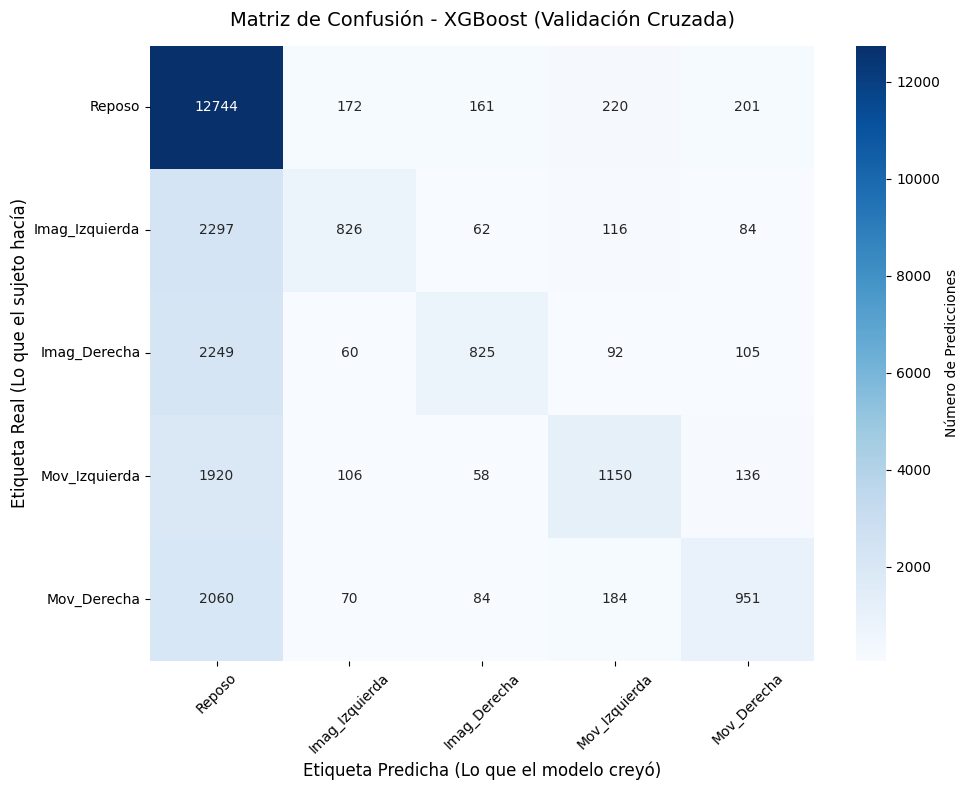


--- REPORTE DETALLADO POR CLASE ---
                precision    recall  f1-score   support

        Reposo       0.60      0.94      0.73     13498
Imag_Izquierda       0.67      0.24      0.36      3385
  Imag_Derecha       0.69      0.25      0.36      3331
 Mov_Izquierda       0.65      0.34      0.45      3370
   Mov_Derecha       0.64      0.28      0.39      3349

      accuracy                           0.61     26933
     macro avg       0.65      0.41      0.46     26933
  weighted avg       0.63      0.61      0.56     26933



In [39]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

print("=== GENERANDO MATRIZ DE CONFUSIÓN (XGBOOST) ===\n")

# 1. Preparar el pipeline con el modelo ganador (XGBoost)
pipeline_xgb = Pipeline([
    ('scaler', StandardScaler()), 
    ('clf', XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42))
])

# 2. Obtener las predicciones para todo el dataset usando validación cruzada (sin Data Leakage)
# Esto simula cómo predice el modelo en datos no vistos
y_pred = cross_val_predict(pipeline_xgb, X_final, y, cv=cv, n_jobs=-1)

# 3. Calcular la Matriz de Confusión
cm = confusion_matrix(y, y_pred)

# 4. Nombres de las clases
# 0: Reposo, 1: Imag_Izquierda, 2: Imag_Derecha, 3: Mov_Izquierda, 4: Mov_Derecha
etiquetas = ['Reposo', 'Imag_Izquierda', 'Imag_Derecha', 'Mov_Izquierda', 'Mov_Derecha']

# 5. Graficar la matriz con Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=etiquetas, yticklabels=etiquetas,
            cbar_kws={'label': 'Número de Predicciones'})

plt.title('Matriz de Confusión - XGBoost (Validación Cruzada)', fontsize=14, pad=15)
plt.ylabel('Etiqueta Real (Lo que el sujeto hacía)', fontsize=12)
plt.xlabel('Etiqueta Predicha (Lo que el modelo creyó)', fontsize=12)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Extra: Mostrar el reporte detallado por clase
from sklearn.metrics import classification_report
print("\n--- REPORTE DETALLADO POR CLASE ---")
print(classification_report(y, y_pred, target_names=etiquetas))

**Diagnóstico del Desempeño y Sesgo del Modelo**

El análisis de la matriz de confusión y el reporte de clasificación revela un problema subyacente de desbalance de clases extremo en el conjunto de datos. La condición de "Reposo" representa aproximadamente el 50% de las instancias totales (13,498 muestras), mientras que las cuatro tareas de imaginación y ejecución motora promedian apenas 3,350 muestras cada una. Este desequilibrio provocó que el algoritmo XGBoost desarrollara un sesgo estadístico hacia la clase mayoritaria para minimizar su función de pérdida global, lo que explica la marcada discrepancia entre el Accuracy global (61%) y el F1-Macro (46%). Fisiológicamente, dado que las desincronizaciones relacionadas con eventos (ERD/ERS) durante las tareas motoras presentan variaciones de amplitud sutiles frente al ritmo base del cerebro, el modelo optó por clasificar sistemáticamente los patrones dudosos como "Reposo", logrando un Recall del 94% para esta clase, pero a costa de ignorar la varianza de las condiciones minoritarias (fenómeno evidenciado en la alta tasa de falsos negativos en la primera columna de la matriz).

Para corregir este sesgo y mejorar la capacidad discriminativa del sistema, es imperativo aplicar técnicas de mitigación de desbalance antes de proceder con el entrenamiento de las arquitecturas de Deep Learning (CNN y LSTM). La primera estrategia consiste en una adaptación algorítmica mediante la Ponderación de Clases (Class Weighting), modificando la función de pérdida de las redes neuronales para que penalicen con mayor severidad los errores cometidos en las clases minoritarias (movimiento e imaginación). De forma complementaria, si el modelo requiere un balanceo a nivel de datos, se implementará la técnica de sobremuestreo sintético SMOTE (Synthetic Minority Over-sampling Technique). Este método generará vectores de características artificiales basados en la interpolación espacial de los datos de la clase minoritaria, garantizando que los modelos de aprendizaje profundo reciban una distribución perfectamente equitativa y se vean forzados a extraer los patrones espectro-espaciales sutiles en lugar de depender de la probabilidad a priori de la clase dominante.

In [ ]:

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_validate
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

print("=== ENTRENAMIENTO CON BALANCEO DE CLASES (SMOTE) ===\n")

# Dejamos SOLO XGBoost
modelos = {
    "XGBoost + SMOTE": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42, n_jobs=-1)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'f1_macro', 'precision_macro', 'recall_macro']
resultados_smote = []

for nombre, modelo in modelos.items():
    print(f"Entrenando {nombre}...")
    
    pipeline = ImbPipeline([
        ('scaler', StandardScaler()), 
        ('smote', SMOTE(random_state=42)), 
        ('clf', modelo)
    ])
    
    
    scores = cross_validate(pipeline, X_final, y, cv=cv, scoring=scoring)
    
    resultados_smote.append({
        'Modelo': nombre,
        'Accuracy': scores['test_accuracy'].mean(),
        'F1_Macro': scores['test_f1_macro'].mean(),
        'Precision': scores['test_precision_macro'].mean(),
        'Recall': scores['test_recall_macro'].mean()
    })

df_resultados_smote = pd.DataFrame(resultados_smote)
print("\n--- RESULTADOS CON SMOTE ---")
print(df_resultados_smote.to_string(index=False))

=== ENTRENAMIENTO CON BALANCEO DE CLASES (SMOTE) ===

Entrenando XGBoost + SMOTE...


c:\Users\Juan Esteban\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\xgboost\training.py:200: UserWarning: [05:49:35] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Juan Esteban\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\xgboost\training.py:200: UserWarning: [05:49:38] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Juan Esteban\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\xgboost\training.py:200: UserWarning: [05:49:40] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Juan Esteban\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\xgboost\training.py:200: UserWarning: 


--- RESULTADOS CON SMOTE ---
         Modelo  Accuracy  F1_Macro  Precision   Recall
XGBoost + SMOTE  0.515687  0.456589   0.446461 0.482641


Para mitigar el sesgo hacia la clase mayoritaria ("Reposo") detectado en el modelo base, se implementó la técnica de sobremuestreo sintético SMOTE (*Synthetic Minority Over-sampling Technique*) integrada estrictamente dentro del *Pipeline* de validación cruzada para evitar la fuga de datos (*Data Leakage*), evaluándose mediante el algoritmo XGBoost. Los resultados evidenciaron una corrección en el comportamiento predictivo: aunque la exactitud global (*Accuracy*) se ajustó a un 51.56% —eliminando la falsa percepción de rendimiento generada por predecir constantemente el reposo—, la sensibilidad promedio (*Recall*) experimentó una mejora al 48.26%, indicando que el modelo aprendió a identificar de forma más equitativa las sutiles tareas de imaginación y ejecución motora. No obstante, el estancamiento del *F1-Macro* en 45.65% confirma que la complejidad no lineal y el solapamiento espectro-espacial de las características EEG han alcanzado el límite resolutivo de los algoritmos tradicionales de Machine Learning, justificando metodológicamente la necesidad de implementar arquitecturas de aprendizaje profundo (Deep Learning) para la siguiente fase del estudio.

In [ ]:
# Creamos un dataframe solo con lo que necesitamos
columnas_guardar = list(columnas_ganadoras) + ['Condicion']
df_colab = df[columnas_guardar]

# Lo exportamos a un CSV limpio
df_colab.to_csv("dataset_bci_optimizado.csv", index=False)

La continuacion con los modelos de clasificacion se siguio en colab, dado que el costo computacional de las los modelos utilizando librerias como TensorFlow estan diseñadas con un enfoque en colab, por tanto, alli su desarrolo se vuelve mas eficaz.

Por tanto, si se quiere ejecutar este codigo, es recomendable subirlo a colab y ejecutarlo alli. Se adjunta en el repositorio con el nombre 'ModelosDeClasificacionP2.ipynb'

Recalcamos subir en colab el anterior archivo descrito y la base de datos 'dataset_BCI_optimizado.csv'
